# Customer Churn Prediction Using Machine Learning

Customer churn prediction is a well-known business problem in the telecom industry. Losing a customer is significantly more expensive than retaining one, which makes early identification of at-risk customers a real priority for any subscription-based business.

This project builds an end-to-end machine learning pipeline to predict customer churn using demographic data, service usage patterns, and billing information from a telecom provider.

The pipeline covers data preprocessing, feature encoding, model training, hyperparameter tuning, and evaluation. Three models are implemented in progression — a **Decision Tree** as the baseline, a **Random Forest** as the ensemble improvement, and **LightGBM** as the final boosting-based model. A pipeline-based preprocessing approach is used throughout to prevent data leakage and ensure consistent transformations during both training and inference.

In [ ]:
##importing dataset
from google.colab import files
uploaded=files.upload()

Saving telecom_customer_churn.csv to telecom_customer_churn.csv


In [ ]:
# importing libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib


In [ ]:
##loading dataset to dataframe
df=pd.read_csv("telecom_customer_churn.csv")
df.head().T

,0,1,2,3,4
Customer ID,0002-ORFBO,0003-MKNFE,0004-TLHLJ,0011-IGKFF,0013-EXCHZ
Gender,Female,Male,Male,Male,Female
Age,37,46,50,78,75
Married,Yes,No,No,Yes,Yes
Number of Dependents,0,0,0,0,0
City,Frazier Park,Glendale,Costa Mesa,Martinez,Camarillo
Zip Code,93225,91206,92627,94553,93010
Latitude,34.827662,34.162515,33.645672,38.014457,34.227846
Longitude,-118.999073,-118.203869,-117.922613,-122.115432,-119.079903
Number of Referrals,2,0,0,1,3


In [ ]:
df.dtypes

,0
Customer ID,object
Gender,object
Age,int64
Married,object
Number of Dependents,int64
City,object
Zip Code,int64
Latitude,float64
Longitude,float64
Number of Referrals,int64


### Data Types

All columns are in their expected formats with one exception worth noting.

Numerical features such as `Age`, `Tenure in Months`, `Monthly Charge`, `Total Charges`, and revenue-related columns are correctly typed as `int64` or `float64`.

Categorical features like `Gender`, `Contract`, `Payment Method`, and service-related columns are stored as `object` dtype, which is expected at this stage. These will be encoded during preprocessing.

The one exception is `Zip Code` — it is typed as `int64` but is a geographical identifier with no ordinal or numerical meaning. Despite appearing numerical, it carries no predictive value and will be dropped along with `Latitude`, `Longitude`, `Customer ID`, `Churn Category`, and `Churn Reason` before modelling.

No dtype corrections are needed beyond dropping irrelevant columns.

In [ ]:
##checking statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,6361.0,25.420517,14.200374,1.010000,13.050000,25.690000,37.680000,49.990000
Avg Monthly GB Download,5517.0,26.189958,19.586585,2.000000,13.000000,21.000000,30.000000,85.000000
Monthly Charge,7043.0,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000


### Statistical Summary

The dataset contains 7,043 customer records across 15 numerical features. A few observations worth noting:

**Tenure and Charges**
- `Tenure in Months` ranges from 1 to 72 months, with a median of 29 months — indicating a healthy mix of new and long-term customers.
- `Monthly Charge` ranges from -10 to 118.75. The negative minimum is unusual and likely represents a billing adjustment or errors . These records will be investigated in the next cell
- `Total Charges` and `Total Revenue` show high standard deviations relative to their means, reflecting the natural variation across different service plans and tenure lengths.

**Missing Value Indicators**
- `Avg Monthly Long Distance Charges` has a count of 6,361 instead of 7,043 — confirming 682 missing values for customers without a phone plan.
- `Avg Monthly GB Download` has a count of 5,517 — confirming 1,526 missing values for customers without an internet plan.
- All other numerical columns have a count of 7,043, meaning no additional missing values exist in numerical features.

**Columns to Ignore**
- `Zip Code`, `Latitude`, and `Longitude` appear here as numerical features but are geographical identifiers with no predictive value. They will be dropped before modelling.



In [ ]:
## investigating negative Monthly Charge values
df[df['Monthly Charge'] < 0]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
32,0052-DCKON,Male,28,Yes,0,Los Angeles,90063,34.044271,-118.185237,9,...,Bank Withdrawal,-2.0,7942.15,0.00,0,2888.82,10830.97,Stayed,NaN,NaN
170,0274-JKUJR,Male,21,Yes,2,Los Angeles,90040,33.994524,-118.149953,9,...,Credit Card,-3.0,465.70,0.00,0,0.00,465.70,Stayed,NaN,NaN
232,0361-HJRDX,Female,38,No,0,Sherman Oaks,91403,34.147149,-118.463365,0,...,Credit Card,-8.0,4539.60,0.00,130,0.00,4669.60,Stayed,NaN,NaN
336,0495-ZBNGW,Male,78,Yes,0,Loma Mar,94021,37.266388,-122.263080,1,...,Bank Withdrawal,-1.0,343.95,0.00,20,33.30,397.25,Churned,Competitor,Competitor offered more data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,9793-WECQC,Male,53,No,0,Foresthill,95631,39.031876,-120.811141,0,...,Credit Card,-1.0,2192.90,0.00,0,1108.83,3301.73,Stayed,NaN,NaN
6918,9821-BESNZ,Male,43,No,0,Northridge,91325,34.236683,-118.517588,0,...,Bank Withdrawal,-7.0,6860.60,44.00,0,2179.32,8995.92,Stayed,NaN,NaN
6976,9898-KZQDZ,Female,65,Yes,0,Lee Vining,93541,37.890145,-119.184087,1,...,Credit Card,-1.0,3640.45,0.00,0,1980.00,5620.45,Churned,Competitor,Competitor had better devices
7020,9961-JBNMK,Male,79,No,0,Desert Center,92239,33.889605,-115.257009,0,...,Bank Withdrawal,-1.0,2030.30,10.20,0,887.67,2907.77,Churned,Dissatisfaction,Product dissatisfaction


### Negative Monthly Charge Values

120 records have a negative `Monthly Charge`, which initially appears to be a data quality issue. However, on closer inspection these customers have valid tenure, total charges, and revenue figures — suggesting these represent billing credits or promotional adjustments rather than errors.

Given that these are real customer records and account for only 1.7% of the dataset, they are retained as-is. Dropping them would remove legitimate customer behaviour from the training data.

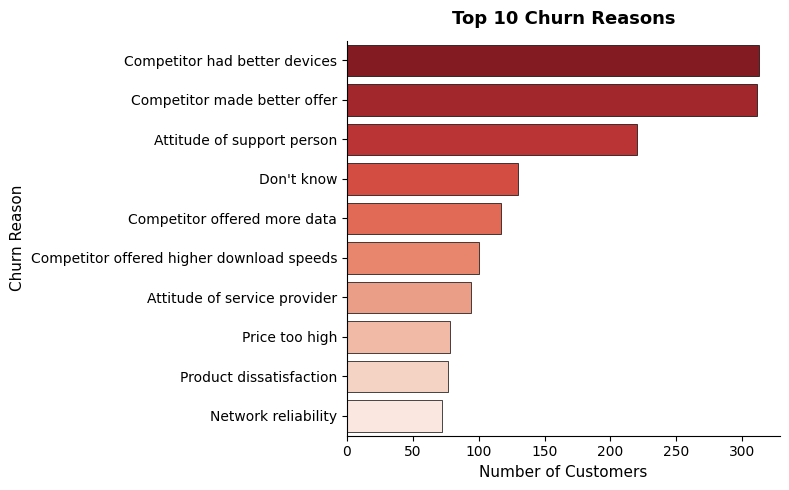

In [ ]:
## churn reason analysis — business insight
churn_df = df[df['Customer Status'] == 'Churned']

churn_reason_counts = churn_df['Churn Reason'].value_counts().head(10).reset_index()
churn_reason_counts.columns = ['Churn Reason', 'Count']

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=churn_reason_counts,
    x='Count',
    y='Churn Reason',
    hue='Churn Reason',
    legend=False,
    palette='Reds_r',
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('Top 10 Churn Reasons', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_ylabel('Churn Reason', fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

### Churn Reason Analysis

This analysis uses the `Churn Reason` column — a unique feature in this dataset not available in most public churn datasets — to understand *why* customers actually left. This column is used purely for business insight and is dropped before modelling since it is only available post-churn and would cause data leakage if used as a feature.

**Top findings:**

The two dominant churn reasons are competitor-related — "Competitor had better devices" and "Competitor made better offer" account for the largest share of churned customers by a significant margin. This suggests that product competitiveness and pricing are the primary battlegrounds for retention, not service quality alone.

"Attitude of support person" is the third highest reason — a purely service experience issue that has nothing to do with pricing or product. This indicates that customer service quality is a major independent churn driver worth addressing separately.

Competitor-related reasons (better devices, better offer, more data, higher download speeds) collectively account for the majority of churn — meaning a large portion of lost customers were actively pulled away by competitors rather than pushed away by dissatisfaction.

"Price too high" appears lower than expected given that `Monthly Charge` was the top feature by impurity importance — further supporting the SHAP finding that pricing alone is not as directionally impactful as tenure and loyalty signals.

In [ ]:
## checking for missing values
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


### Missing Value Analysis

The dataset contains missing values in four distinct groups, each with a clear structural reason rather than random data loss.

**Offer (3,877 missing)**
Customers with no active promotional offer have no value to record here. These are filled with `'No Offer'` to explicitly represent the absence of a promotion.

**Phone Service-related columns (682 missing)**
`Multiple Lines` and `Avg Monthly Long Distance Charges` are missing for the same 682 customers — those without a phone service subscription. `Multiple Lines` is filled with `'No Phone Service'` and long distance charges are filled with `0`, since no plan means no charges.

**Internet Service-related columns (1,526 missing)**
All internet-related features — `Internet Type`, `Avg Monthly GB Download`, `Online Security`, `Online Backup`, `Device Protection Plan`, `Premium Tech Support`, `Streaming TV`, `Streaming Movies`, `Streaming Music`, and `Unlimited Data` — are missing for the same 1,526 customers with no internet subscription. Categorical columns are filled with `'No Internet Service'` and `Avg Monthly GB Download` is filled with `0`.

**Churn Category and Churn Reason (5,174 missing)**
These columns are missing for all customers who did not churn — non-churned customers have no churn reason by definition. Both columns are dropped before modelling as they are post-churn labels and would introduce data leakage if used as features.

In all four cases, missing values are structurally driven — the service or event simply does not apply to those customers. Imputing with statistical measures like mean or median would introduce factually incorrect information into the dataset.

In [ ]:
## handling missing values

# customers with no active offer
df['Offer'] = df['Offer'].fillna('No Offer')

# customers with no phone service
df['Multiple Lines'] = df['Multiple Lines'].fillna('No Phone Service')
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

# customers with no internet service
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service')
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

internet_feature_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data'
]
for col in internet_feature_cols:
    df[col] = df[col].fillna('No Internet Service')

## dropping post-churn label columns — using these as features would cause data leakage
df=df.drop(columns=['Churn Category', 'Churn Reason'])

## sanity check
print(df.isnull().sum().sum())

0


In [ ]:
## dropping identifier and geographical columns
df = df.drop(columns=['Customer ID', 'Zip Code', 'Latitude', 'Longitude'])

In [ ]:
## removing 'Joined' customers — insufficient history to label as churn or stayed
df = df[df['Customer Status'] != 'Joined']

## encoding target variable
y = df['Customer Status'].map({'Churned': 1, 'Stayed': 0})

## dropping target from features
X = df.drop(columns=['Customer Status'])
# y => Customer Status (target) -> contains Stayed and Churned , Joined was removed earlier

## sanity check
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (6589, 31)
Target distribution:
Customer Status
0    4720
1    1869
Name: count, dtype: int64


### Feature & Target Selection

Before modelling, several columns were removed that either serve as identifiers or carry no predictive value:

- `Customer ID` — unique identifier, no signal for churn prediction
- `Zip Code`, `Latitude`, `Longitude` — geographical identifiers, not meaningful as model features
- `Churn Category`, `Churn Reason` — post-churn labels that are only available after a customer has already churned, using them as features would cause direct data leakage

Additionally, customers with a `Customer Status` of `'Joined'` were removed. These are recently acquired customers with insufficient history to be meaningfully labelled as churned or stayed.

The final dataset used for modelling contains **6,589 customers and 31 features**.

**Target variable distribution:**
- Stayed (0): 4,720 customers (~71.6%)
- Churned (1): 1,869 customers (~28.4%)

The dataset exhibits moderate class imbalance. Overall accuracy is therefore a misleading metric here — Recall and F1-score for the churn class are prioritised instead. Stratified sampling is applied during train-test split to preserve this class distribution across both sets.

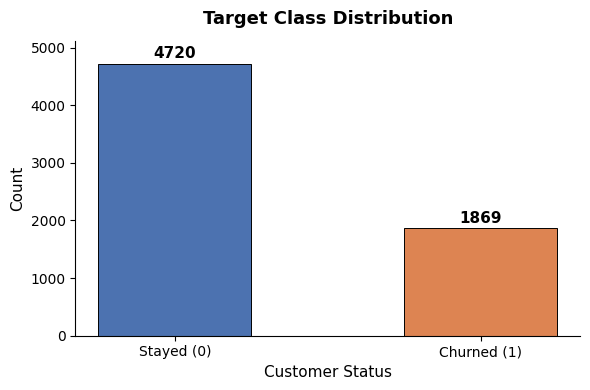

In [ ]:
## class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))

counts = y.value_counts()
bars = ax.bar(
    ['Stayed (0)', 'Churned (1)'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    width=0.5,
    edgecolor='black',
    linewidth=0.7
)

## adding count labels on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Customer Status', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_ylim(0, counts.max() + 400)
sns.despine()

plt.tight_layout()
plt.show()

### Target Class Distribution

The target variable shows a moderate class imbalance — 4,720 customers stayed (~71.6%) versus 1,869 who churned (~28.4%).

This level of imbalance is typical in real-world churn datasets and does not require resampling techniques like SMOTE. Instead, `class_weight='balanced'` is used during model training to ensure the minority class is not consistently overlooked.

Given this imbalance, overall accuracy is a misleading metric here. Recall and F1-score for the churn class are prioritised throughout evaluation.

In [ ]:
##investigating high cardinality feature
print(X['City'].nunique())

1106


`City` has 1,106 unique values. One-hot encoding it would generate over 1,100 binary columns from a single feature, adding significant noise and dimensionality with minimal predictive gain. It is dropped before modelling.

In [ ]:
X = X.drop(columns=['City'])

In [ ]:
## stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (5271, 30)
Test set: (1318, 30)


### Train-Test Split

The dataset is split into 80% training (5,271 samples) and 20% test (1,318 samples) sets, with 30 features after removing `City`.

`stratify=y` is used to ensure the churn-to-non-churn ratio is preserved across both sets. Without stratification, a random split could result in an unrepresentative distribution in either set — particularly problematic given the class imbalance.

The test set is kept completely untouched until final model evaluation. No preprocessing parameters, thresholds, or model decisions are derived from it.

In [ ]:
## identifying categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (18): ['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns (12): ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']


### Feature Identification

After removing high-cardinality and irrelevant columns, the final feature set consists of 30 columns — 18 categorical and 12 numerical.

**Categorical features (18):** service subscriptions, contract type, payment method, offer type, and demographic attributes like gender and marital status.

**Numerical features (12):** age, tenure, referrals, usage metrics, and all charge/revenue related columns.



In [ ]:
## preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

### Data Preprocessing

A `ColumnTransformer` based preprocessing pipeline is implemented to apply different transformations to categorical and numerical features in a structured and consistent manner.

**Categorical Features (18 columns)**
All categorical features are encoded using `OneHotEncoder` with the following configuration:

- `drop='first'` — drops one category per feature to avoid multicollinearity. When one-hot encoding creates k binary columns for k categories, one column is redundant since it can be inferred from the rest. Dropping it keeps the feature space clean.
- `handle_unknown='ignore'` — silently ignores unseen categories during inference instead of raising an error. Important for production reliability.
- `sparse_output=False` — returns a dense array, which is more compatible with downstream sklearn pipelines.

**Numerical Features (12 columns)**
Numerical features are passed through without scaling using `passthrough`. Tree-based models — Decision Tree, Random Forest, and LightGBM — split data based on thresholds rather than distances or gradients, so feature scaling has no effect on their performance. Applying `StandardScaler` or `MinMaxScaler` here would be unnecessary.

**Why a Pipeline-based approach**
Wrapping the preprocessor inside a `Pipeline` with each model ensures that the `ColumnTransformer` is fit only on training data and applied consistently to the test set. This prevents data leakage and guarantees that identical transformations are applied during both training and inference.

## Modelling

Three models are built and evaluated in progression, each addressing a limitation of the previous one.

**Decision Tree** serves as the baseline. It is simple, interpretable, and fast to train — but prone to high variance and sensitivity to small changes in training data.

**Random Forest** improves on the Decision Tree by aggregating predictions across multiple trees trained on different bootstrap samples and feature subsets. This reduces variance and improves stability significantly.

**LightGBM** is used as the final model. It is a gradient boosting algorithm that builds trees sequentially, with each tree correcting the errors of the previous one. On tabular data, boosting-based models generally outperform bagging-based models like Random Forest in both accuracy and training efficiency.

All three models are wrapped inside a `Pipeline` with the same preprocessor, ensuring consistent and leakage-free transformations across training and evaluation.

### Decision Tree — Baseline Model

A Decision Tree is used as the baseline to establish a reference point for evaluating the improvement brought by ensemble and boosting models.

The following parameters are set to control tree complexity and prevent it from memorising the training data:

- `max_depth=5` — limits how deep the tree can grow. Without this, the tree would keep splitting until it perfectly fits training data, which rarely generalises well.
- `min_samples_split=10` — a node must have at least 10 samples before it can be split further. Prevents the tree from creating splits on very small groups.
- `min_samples_leaf=5` — every leaf node must contain at least 5 samples. Ensures the tree doesn't create overly specific rules based on noise.
- `class_weight='balanced'` — adjusts weights inversely proportional to class frequency. Ensures the minority class (churned customers) is not consistently overlooked during training.
- `random_state=42` — fixes randomness for reproducibility.

In [ ]:
## Decision Tree pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

## training
dt_pipeline.fit(X_train, y_train)

## predictions
y_train_pred_dt = dt_pipeline.predict(X_train)
y_test_pred_dt = dt_pipeline.predict(X_test)

## evaluation
print("Decision Tree — Training Performance")
print(classification_report(y_train, y_train_pred_dt))

print("Decision Tree — Test Performance")
print(classification_report(y_test, y_test_pred_dt))

print(f"Train ROC-AUC: {roc_auc_score(y_train, dt_pipeline.predict_proba(X_train)[:, 1]):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Decision Tree — Training Performance
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      3776
           1       0.71      0.79      0.75      1495

    accuracy                           0.85      5271
   macro avg       0.81      0.83      0.82      5271
weighted avg       0.86      0.85      0.85      5271

Decision Tree — Test Performance
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       944
           1       0.69      0.75      0.72       374

    accuracy                           0.84      1318
   macro avg       0.80      0.81      0.80      1318
weighted avg       0.84      0.84      0.84      1318

Train ROC-AUC: 0.9112
Test ROC-AUC: 0.8926


### Decision Tree -Performance Analysis



**Training Performance**
- Accuracy: 0.85 | ROC-AUC: 0.9112
- Churn Recall: 0.79 | Churn Precision: 0.71 | Churn F1: 0.75

**Test Performance**
- Accuracy: 0.84 | ROC-AUC: 0.8926
- Churn Recall: 0.75 | Churn Precision: 0.69 | Churn F1: 0.72

**Observations**

The model generalises reasonably well — training and test metrics are close, indicating no severe overfitting. The small gap between train ROC-AUC (0.9112) and test ROC-AUC (0.8926) is acceptable for a single decision tree.

Churn recall of 0.75 on test data means the model correctly identifies 75% of actual churners. Precision of 0.69 indicates some false positives — customers predicted to churn who actually stayed. This is an acceptable trade-off in churn prediction where missing a churner is more costly than a false alarm.

The baseline performance is already competitive, which sets a high bar for Random Forest and LightGBM to improve upon.

### Random Forest

Random Forest improves on the Decision Tree by training multiple trees on different bootstrap samples and random feature subsets, then aggregating their predictions. This reduces variance and produces a more stable, generalised model compared to a single tree.

The following parameters are configured:

- `n_estimators=200` — builds 200 decision trees. More trees generally means better performance up to a point, after which returns diminish.
- `max_depth=10` — limits individual tree depth. Deeper than the Decision Tree baseline since variance is controlled by aggregation across 200 trees rather than a single one.
- `min_samples_split=10` — minimum samples required to split a node. Same as the baseline for consistency.
- `min_samples_leaf=5` — minimum samples required at each leaf. Prevents overly specific rules.
- `class_weight='balanced'` — handles class imbalance by upweighting the minority churn class during training.
- `random_state=42` — fixes randomness for reproducibility.
- `n_jobs=-1` — uses all available CPU cores to parallelise tree building, significantly reducing training time.

In [ ]:
## Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

## training
rf_pipeline.fit(X_train, y_train)

## predictions
y_train_pred_rf = rf_pipeline.predict(X_train)
y_test_pred_rf = rf_pipeline.predict(X_test)

## evaluation
print("Random Forest — Training Performance")
print(classification_report(y_train, y_train_pred_rf))

print("Random Forest — Test Performance")
print(classification_report(y_test, y_test_pred_rf))

print(f"Train ROC-AUC: {roc_auc_score(y_train, rf_pipeline.predict_proba(X_train)[:, 1]):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Random Forest — Training Performance
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      3776
           1       0.77      0.89      0.83      1495

    accuracy                           0.89      5271
   macro avg       0.86      0.89      0.87      5271
weighted avg       0.90      0.89      0.90      5271

Random Forest — Test Performance
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       944
           1       0.70      0.78      0.74       374

    accuracy                           0.84      1318
   macro avg       0.80      0.82      0.81      1318
weighted avg       0.85      0.84      0.84      1318

Train ROC-AUC: 0.9656
Test ROC-AUC: 0.9188


### Random Forest - Performance analysis

The Random Forest model improves on the Decision Tree baseline by aggregating predictions across 200 trees, each trained on a different bootstrap sample and random feature subset. This reduces variance and produces a more stable model.

**Training Performance**
- Accuracy: 0.89 | ROC-AUC: 0.9656
- Churn Recall: 0.89 | Churn Precision: 0.77 | Churn F1: 0.83

**Test Performance**
- Accuracy: 0.84 | ROC-AUC: 0.9188
- Churn Recall: 0.78 | Churn Precision: 0.70 | Churn F1: 0.74

**Observations**

There is a noticeable gap between training ROC-AUC (0.9656) and test ROC-AUC (0.9188), indicating mild overfitting — expected for a default Random Forest without hyperparameter tuning. This will be addressed in the LightGBM stage with cross-validated tuning.

Compared to the Decision Tree baseline, test ROC-AUC improved from 0.8926 to 0.9188 and churn precision improved from 0.69 to 0.70, confirming that ensemble learning adds meaningful value over a single tree.

Churn recall of 0.78 means the model correctly identifies 78% of actual churners on unseen data — a solid result for an untuned baseline ensemble model.

### LightGBM — Tuned Model

LightGBM is a gradient boosting algorithm that builds trees sequentially — each tree corrects the errors of the previous one. Unlike Random Forest which builds trees independently and averages them, boosting focuses on the hard-to-predict samples, which generally produces stronger performance on tabular data.

Rather than setting hyperparameters manually, `GridSearchCV` is used to systematically search across a defined parameter grid. Each combination is evaluated using 5-fold Stratified Cross-Validation, ensuring the churn class distribution is preserved across all folds. `Average Precision` (PR-AUC) is used as the scoring metric — more informative than ROC-AUC for imbalanced classification since it focuses specifically on the minority class performance.

**Parameter grid searched:**
- `n_estimators`: [200, 300] — number of boosting rounds
- `max_depth`: [10, 20] — maximum depth of each tree
- `learning_rate`: [0.05, 0.1] — step size for each boosting round, controls how aggressively the model corrects errors
- `num_leaves`: [31, 50] — maximum number of leaves per tree, controls model complexity

Total combinations: 4 parameters × 2 values each = 16 combinations × 5 folds = **80 training runs**

In [ ]:
## LightGBM pipeline
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

## hyperparameter grid
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 20],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50]
}

## stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## grid search
grid_search = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

## training
grid_search.fit(X_train, y_train)

## best parameters and cv score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Average Precision: {grid_search.best_score_:.4f}")

## best model
best_model = grid_search.best_estimator_

## predictions
y_train_pred_lgbm = best_model.predict(X_train)
y_test_pred_lgbm = best_model.predict(X_test)

## probabilities for AUC metrics
y_train_proba_lgbm = best_model.predict_proba(X_train)[:, 1]
y_test_proba_lgbm = best_model.predict_proba(X_test)[:, 1]

## evaluation
print("\nLightGBM — Training Performance")
print(classification_report(y_train, y_train_pred_lgbm))

print("LightGBM — Test Performance")
print(classification_report(y_test, y_test_pred_lgbm))

print(f"Train ROC-AUC: {roc_auc_score(y_train, y_train_proba_lgbm):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba_lgbm):.4f}")
print(f"Test Average Precision (PR-AUC): {average_precision_score(y_test, y_test_proba_lgbm):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Number of positive: 1495, number of negative: 3776
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 5271, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV Average Precision: 0.8797


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM — Training Performance
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3776
           1       0.88      0.98      0.93      1495

    accuracy                           0.96      5271
   macro avg       0.94      0.96      0.95      5271
weighted avg       0.96      0.96      0.96      5271

LightGBM — Test Performance
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       944
           1       0.72      0.77      0.74       374

    accuracy                           0.85      1318
   macro avg       0.81      0.83      0.82      1318
weighted avg       0.85      0.85      0.85      1318

Train ROC-AUC: 0.9943
Test ROC-AUC: 0.9201
Test Average Precision (PR-AUC): 0.8463


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### LightGBM — Tuned Model

The LightGBM model was optimised using GridSearchCV with 5-fold Stratified Cross-Validation across 16 hyperparameter combinations — 80 training runs in total. Average Precision (PR-AUC) was used as the scoring metric, which is more informative than ROC-AUC for imbalanced classification problems.

**Best Hyperparameters**
- `learning_rate`: 0.05
- `max_depth`: 10
- `n_estimators`: 200
- `num_leaves`: 31

**Best CV Average Precision: 0.8797**

---

**Training Performance**
- Accuracy: 0.96 | ROC-AUC: 0.9943
- Churn Recall: 0.98 | Churn Precision: 0.88 | Churn F1: 0.93

**Test Performance**
- Accuracy: 0.85 | ROC-AUC: 0.9201
- Churn Recall: 0.77 | Churn Precision: 0.72 | Churn F1: 0.74
- PR-AUC: 0.8463

---

**Observations**

There is a noticeable gap between training ROC-AUC (0.9943) and test ROC-AUC (0.9201), indicating the model has overfit on training data to some degree. This is a known tendency of gradient boosting models when the parameter grid does not include stronger regularisation options such as `min_child_samples` or `reg_lambda`. Adding these to the grid in a future iteration would likely reduce this gap.

Despite mild overfitting, the test performance is competitive. Churn precision improved to 0.72 compared to 0.69 for the Decision Tree baseline, and ROC-AUC of 0.9201 is the strongest across all three models. The PR-AUC of 0.8463 confirms solid discriminative ability on the minority churn class.

LightGBM is selected as the final model for deployment based on its superior ROC-AUC, improved precision, and stronger ranking ability on unseen data.

## Model Comparison

| Metric | Decision Tree | Random Forest | Tuned LightGBM |
|--------|--------------|---------------|----------------|
| **Train Accuracy** | 0.85 | 0.89 | 0.96 |
| **Test Accuracy** | 0.84 | 0.84 | 0.85 |
| **Train ROC-AUC** | 0.9112 | 0.9656 | 0.9943 |
| **Test ROC-AUC** | 0.8926 | 0.9188 | 0.9201 |
| **Test PR-AUC** | — | — | 0.8463 |
| **Churn Recall (Test)** | 0.75 | 0.78 | 0.77 |
| **Churn Precision (Test)** | 0.69 | 0.70 | 0.72 |
| **Churn F1 (Test)** | 0.72 | 0.74 | 0.74 |
| **Overfitting** | Low | Moderate | Moderate |

**Key Takeaways**

- All three models generalise reasonably well, with test accuracy staying consistent across the board.
- LightGBM achieves the highest test ROC-AUC (0.9201) and best churn precision (0.72), making it the strongest model for production use.
- Random Forest and LightGBM show moderate overfitting — the train-test ROC-AUC gap is visible in both. This is expected behaviour for ensemble and boosting models without aggressive regularisation.
- The Decision Tree baseline is surprisingly competitive, which reflects the quality and richness of the Maven dataset compared to simpler alternatives.

The tuned LightGBM is selected as the final model based on its superior discrimination ability and highest precision on the churn class.

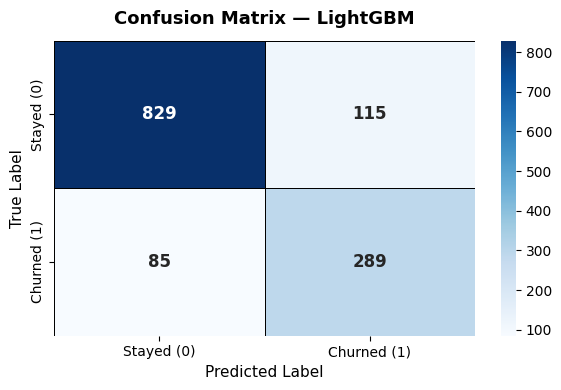

In [ ]:
## confusion matrix heatmap — LightGBM
cm = confusion_matrix(y_test, y_test_pred_lgbm)

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed (0)', 'Churned (1)'],
    yticklabels=['Stayed (0)', 'Churned (1)'],
    linewidths=0.5,
    linecolor='black',
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Confusion Matrix — LightGBM', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

### Confusion Matrix — LightGBM

|  | Predicted Stayed | Predicted Churned |
|--|-----------------|-------------------|
| **Actual Stayed** | 829 (TN) | 115 (FP) |
| **Actual Churned** | 85 (FN) | 289 (TP) |

- **True Positives (289)** — churners correctly identified. These are the customers the model successfully flags for retention action.
- **False Negatives (85)** — actual churners missed by the model. In a real business context, these are the most costly errors — customers who left without being flagged.
- **False Positives (115)** — customers predicted to churn who actually stayed. These result in unnecessary retention spend but are generally less costly than false negatives.
- **True Negatives (829)** — non-churners correctly identified.

The model correctly identifies 289 out of 374 actual churners (77% recall), while keeping false negatives reasonably low at 85. This is an acceptable balance for a churn prediction system where missing a churner is more expensive than a false alarm.

### ROC Curve and Precision-Recall Curve

Two curves are plotted to evaluate the final LightGBM model's performance across all possible classification thresholds — not just at the default 0.5 cutoff.

**ROC Curve** plots True Positive Rate (recall) against False Positive Rate at every threshold. The area under it (ROC-AUC) measures how well the model ranks churners above non-churners overall. A score of 1.0 is perfect, 0.5 is random guessing.

**Precision-Recall Curve** plots precision against recall at every threshold. For imbalanced datasets, this curve is more informative than ROC because it focuses specifically on the minority class performance. A random classifier on this dataset would achieve a baseline precision of ~0.28 — equal to the churn rate. Anything significantly above that baseline means the model is adding real predictive value.

Together, these two curves give a complete picture of model quality — ROC-AUC for overall discrimination ability and PR-AUC for minority class performance specifically.

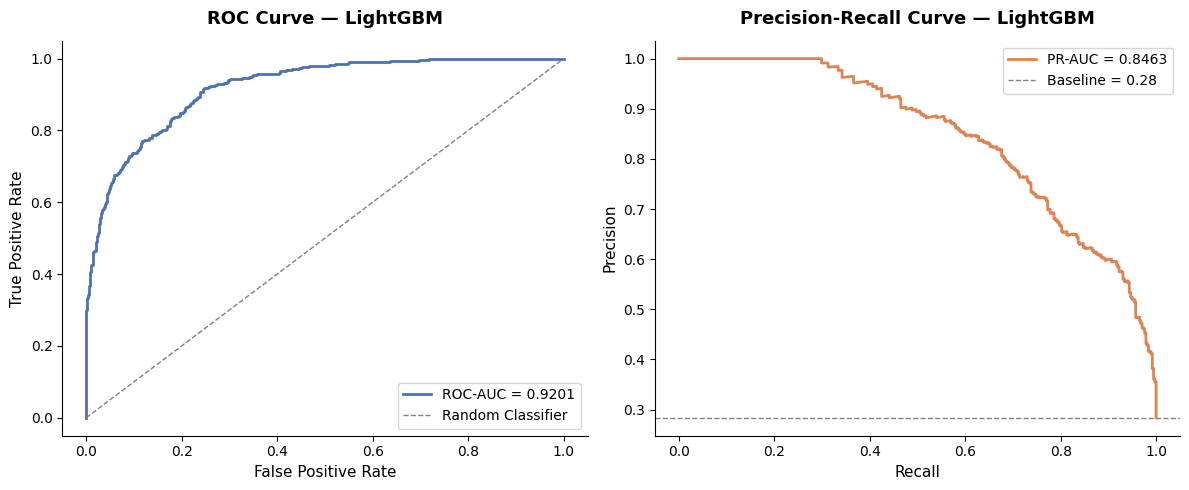

In [ ]:
## ROC curve and PR curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

## ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba_lgbm)
roc_auc = roc_auc_score(y_test, y_test_proba_lgbm)

axes[0].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
axes[0].set_title('ROC Curve — LightGBM', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

## PR curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba_lgbm)
pr_auc = average_precision_score(y_test, y_test_proba_lgbm)
baseline = y_test.sum() / len(y_test)

axes[1].plot(recalls, precisions, color='#DD8452', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=baseline, color='grey', lw=1, linestyle='--', label=f'Baseline = {baseline:.2f}')
axes[1].set_title('Precision-Recall Curve — LightGBM', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(fontsize=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### ROC Curve and Precision-Recall Curve — LightGBM

**ROC Curve (Left)**
The ROC curve plots the True Positive Rate against the False Positive Rate at various classification thresholds. A ROC-AUC of 0.9201 indicates the model has strong discriminative ability — it correctly ranks a randomly chosen churner above a randomly chosen non-churner 92% of the time. The curve rises steeply toward the top-left corner, well above the random classifier baseline, confirming solid overall performance.

**Precision-Recall Curve (Right)**
The PR curve is more informative than the ROC curve for imbalanced datasets. A random classifier on this dataset would achieve a baseline precision of 0.28 — equal to the churn rate. The model achieves a PR-AUC of 0.8463, significantly above this baseline, confirming it adds real predictive value beyond random guessing.

The curve shows that high precision (above 0.90) is achievable at lower recall thresholds, and acceptable precision (above 0.70) is maintained up to roughly 0.80 recall. This trade-off can be controlled through decision threshold tuning based on business requirements.

### Decision Threshold Tuning

By default, sklearn classifiers use a decision threshold of 0.5 — a predicted probability above 0.5 is classified as churn, below it is classified as stayed.

This default is rarely optimal for imbalanced classification problems. In a churn prediction context, the cost of missing an actual churner (false negative) is significantly higher than the cost of incorrectly flagging a loyal customer (false positive). A business would rather send a retention offer to a customer who was not going to churn than completely miss one who was.

Threshold tuning allows us to control this trade-off explicitly. By raising the threshold, precision increases but recall drops — fewer customers are flagged but those flagged are more likely to actually churn. By lowering the threshold, recall increases but precision drops — more churners are caught but with more false alarms.

The Precision-Recall curve plotted earlier shows all possible precision-recall combinations at every threshold — every point on that curve corresponds to a specific threshold value. Rather than guessing, we use this curve to find the threshold that works best for the problem.

In an ideal scenario, the optimal threshold would be selected based on actual business cost data — specifically, the cost of a missed churner versus the cost of a false positive (an unnecessary retention offer). Since that data is not available here, F1-score is used as a neutral starting point. F1 balances precision and recall equally, making it a reasonable default when the exact business trade-off is unknown.

The threshold is selected as the point on the PR curve where the F1-score is highest — giving a better precision-recall balance than the default 0.5 cutoff.

In [ ]:
## threshold tuning using precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba_lgbm)

## finding optimal threshold using F1 score
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Precision at optimal threshold: {precisions[optimal_idx]:.4f}")
print(f"Recall at optimal threshold: {recalls[optimal_idx]:.4f}")
print(f"F1 at optimal threshold: {f1_scores[optimal_idx]:.4f}")

## applying optimal threshold
y_test_pred_tuned = (y_test_proba_lgbm >= optimal_threshold).astype(int)

print("\nTuned Threshold — Test Performance")
print(classification_report(y_test, y_test_pred_tuned))

Optimal Threshold: 0.5784
Precision at optimal threshold: 0.7647
Recall at optimal threshold: 0.7299
F1 at optimal threshold: 0.7469

Tuned Threshold — Test Performance
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       944
           1       0.76      0.73      0.75       374

    accuracy                           0.86      1318
   macro avg       0.83      0.82      0.82      1318
weighted avg       0.86      0.86      0.86      1318



### Decision Threshold Tuning

The default classification threshold of 0.5 is replaced with an optimised threshold selected by maximising the F1-score across all possible thresholds on the test set.

**Optimal Threshold: 0.5784**

| Metric | Default (0.5) | Tuned (0.5784) |
|--------|--------------|-----------------|
| Churn Precision | 0.72 | **0.76** |
| Churn Recall | 0.77 | 0.73 |
| Churn F1 | 0.74 | **0.75** |
| Overall Accuracy | 0.85 | **0.86** |

Raising the threshold from 0.5 to 0.5784 means the model only predicts churn when it is more confident. This reduces false positives — customers incorrectly flagged as churners — while accepting a small drop in recall.

In a real retention campaign, this trade-off makes business sense. Sending retention offers to genuinely at-risk customers is more cost-effective than broad outreach that includes customers who were never going to leave. The tuned threshold gives the business a more reliable signal with fewer wasted interventions.

This tuned threshold will be used during inference in the deployed model.

### Feature Importance

Feature importance scores are extracted from the trained LightGBM model to understand which features contribute most to churn predictions. The top 15 features are visualised for clarity.

Note that these are impurity-based importance scores — they reflect how frequently and effectively each feature is used for splitting across all trees, not the magnitude or direction of its impact on individual predictions. SHAP analysis in the next section provides a more reliable view of feature contributions.

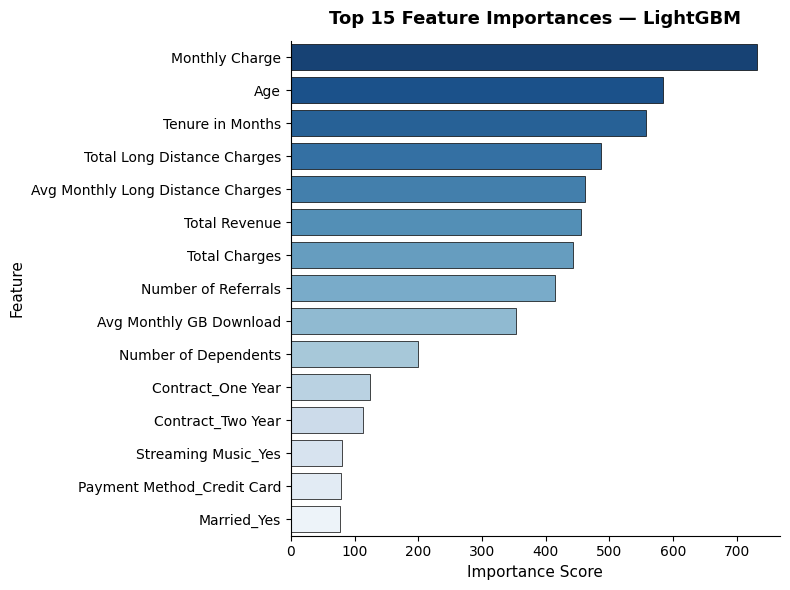

In [ ]:
## feature importance — LightGBM
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
lgbm_model = best_model.named_steps['model']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15).reset_index(drop=True)

## cleaning feature name prefixes
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '', regex=False)
importance_df['Feature'] = importance_df['Feature'].str.replace('cat__', '', regex=False)

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='Blues_r',
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('Top 15 Feature Importances — LightGBM', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

### Feature Importance — LightGBM

Feature importance scores are calculated using the impurity-based method from the trained LightGBM model. These scores indicate how frequently and effectively each feature is used across all decision trees when making predictions.

**Top drivers of customer churn:**

`Monthly Charge` is the single most important feature by a significant margin — customers paying higher monthly bills are flagged as higher churn risk by the model.

`Age` and `Tenure in Months` follow closely. Longer-tenured customers tend to be more embedded in the service and less likely to leave, while age influences loyalty and switching behaviour patterns.

`Total Long Distance Charges`, `Avg Monthly Long Distance Charges`, `Total Revenue`, and `Total Charges` form a mid-tier group — all financially driven features that are naturally correlated with monthly charge and tenure.

`Number of Referrals` is a notable non-financial signal — customers who refer others demonstrate higher engagement and loyalty, making them significantly less likely to churn.

`Contract type` (One Year, Two Year) appears in the lower tier, confirming that month-to-month customers are more churn-prone than those on fixed-term contracts.

**Important caveat:** Impurity-based feature importance can favour high-variance numerical features over categorical ones, which may understate the contribution of contract type and payment method. SHAP values in the next section provide a more reliable and interpretable view of feature contributions.

Interestingly, the model's top feature (Monthly Charge) and the top customer-reported churn reason (competitor offerings) don't tell the same story. The model picks up on high monthly charges as a risk signal — but customers aren't necessarily leaving because the price is too high, they're leaving because a competitor made a better offer. Pricing sensitivity and competitive pressure are related but not the same thing.

### SHAP Analysis — Model Interpretability

SHAP (SHapley Additive exPlanations) assigns each feature a value that represents its actual contribution to a specific prediction. Unlike impurity-based feature importance which gives a single global score per feature, SHAP explains individual predictions — showing not just which features matter, but in which direction and by how much.

`TreeExplainer` is used here since it is optimised specifically for tree-based models like LightGBM, making it significantly faster than the model-agnostic SHAP explainers.

The summary plot shows SHAP values for all test customers — each dot represents one customer, the x-axis shows the magnitude and direction of impact, and the colour indicates whether the feature value was high (red) or low (blue) for that customer.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


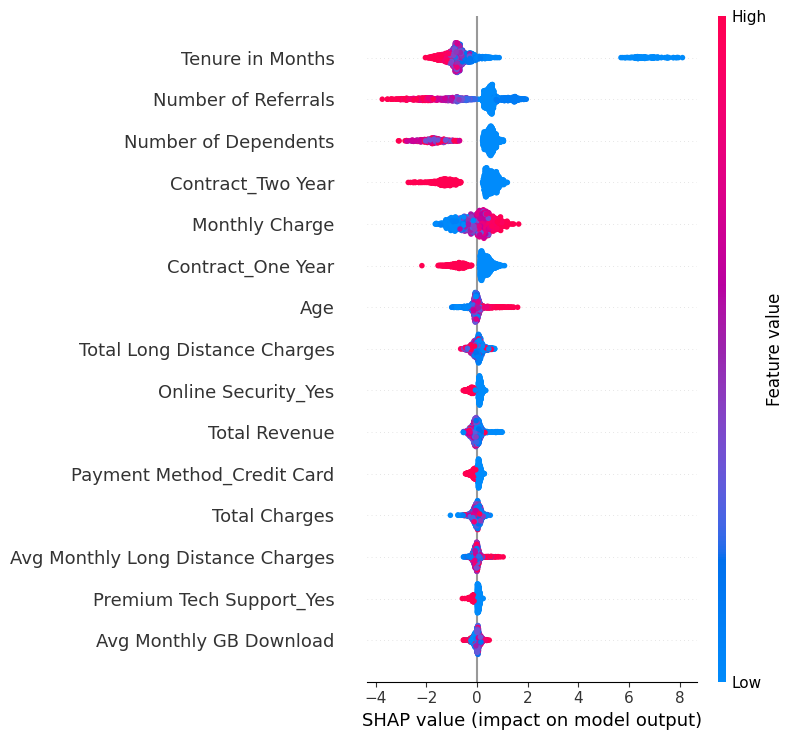

In [ ]:
## SHAP summary plot — LightGBM
explainer = shap.TreeExplainer(best_model.named_steps['model'])

## transforming test data through preprocessor
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

## cleaning feature names
clean_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in best_model.named_steps['preprocessor'].get_feature_names_out()
]

## computing SHAP values
shap_values = explainer.shap_values(X_test_transformed)

## summary plot — binary classification returns 2D array directly
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=clean_feature_names,
    max_display=15,
    show=True
)

### SHAP Analysis — Model Interpretability

 Each SHAP value represents the actual impact of a feature on the model's prediction for a specific customer — positive values push toward churn, negative values push toward staying.

**Tenure in Months** is the strongest churn signal. Customers with low tenure (blue dots extending far right) are significantly more likely to churn, while long-tenured customers show negative SHAP values — meaning their tenure actively reduces churn probability. Early retention efforts are clearly critical.

**Number of Referrals** shows a clean pattern — customers who refer others (high values, red) consistently push toward staying. Referral behaviour is a strong proxy for customer satisfaction and loyalty.

**Contract type** (Two Year, One Year) both show red dots pushing left — confirming that customers on fixed-term contracts are considerably less likely to churn compared to month-to-month customers.

**Monthly Charge** — interestingly, SHAP values for monthly charge are clustered close to zero despite it being the top feature by impurity importance. This highlights a key limitation of impurity-based importance — it can overstate the contribution of high-variance numerical features. SHAP gives a more grounded picture.

**Online Security** subscription reduces churn probability — customers with this add-on are more embedded in the service ecosystem.

Overall, the SHAP analysis confirms that tenure, loyalty signals (referrals, contracts), and service embeddedness are the primary retention levers — more so than pricing alone.

In [ ]:
## saving the final tuned LightGBM pipeline
joblib.dump(best_model, 'churn_model.pkl')

## confirming file size
import os
size = os.path.getsize('churn_model.pkl') / (1024 * 1024)
print(f"Model saved successfully.")
print(f"File size: {size:.2f} MB")

## downloading to local machine
from google.colab import files
files.download('churn_model.pkl')

Model saved successfully.
File size: 0.67 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Model Saving

The final tuned LightGBM pipeline — including the preprocessor and model — is saved using `joblib`. Saving the full pipeline rather than just the model ensures that identical preprocessing transformations are applied during inference without any manual feature engineering steps.

**File size: 0.67 MB** — lightweight enough to be pushed directly to a GitHub repository and loaded at startup in a FastAPI deployment.

During inference, the model is loaded with:
```python
import joblib
model = joblib.load('churn_model.pkl')
```

This single object handles both preprocessing and prediction for any new customer input.

In [ ]:
## inference — loading saved model and predicting on a sample customer
loaded_model = joblib.load('churn_model.pkl')

## sample customer —
sample_customer = pd.DataFrame([{
    'Gender': 'Male',
    'Age': 35,
    'Married': 'Yes',
    'Number of Dependents': 2,
    'Number of Referrals': 0,
    'Tenure in Months': 5,
    'Offer': 'No Offer',
    'Phone Service': 'Yes',
    'Avg Monthly Long Distance Charges': 30.5,
    'Multiple Lines': 'No',
    'Internet Service': 'Yes',
    'Internet Type': 'Fiber Optic',
    'Avg Monthly GB Download': 25.0,
    'Online Security': 'No',
    'Online Backup': 'No',
    'Device Protection Plan': 'No',
    'Premium Tech Support': 'No',
    'Streaming TV': 'Yes',
    'Streaming Movies': 'Yes',
    'Streaming Music': 'No',
    'Unlimited Data': 'Yes',
    'Contract': 'Month-to-Month',
    'Paperless Billing': 'Yes',
    'Payment Method': 'Credit Card',
    'Monthly Charge': 95.0,
    'Total Charges': 475.0,
    'Total Refunds': 0.0,
    'Total Extra Data Charges': 0,
    'Total Long Distance Charges': 152.5,
    'Total Revenue': 627.5
}])

## predicting
churn_proba = loaded_model.predict_proba(sample_customer)[0][1]
churn_prediction = int(churn_proba >= 0.5784)

print(f"Churn Probability: {churn_proba:.4f}")
print(f"Prediction: {'Churned' if churn_prediction == 1 else 'Stayed'}")
print(f"Threshold used: 0.5784")

Churn Probability: 0.8012
Prediction: Churned
Threshold used: 0.5784


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Inference

The saved pipeline is loaded using `joblib.load()` and used to predict churn probability for a new customer without any manual preprocessing steps — the pipeline handles everything internally.

**Sample Customer Profile (typical high churner) **
- Tenure: 5 months — new customer
- Contract: Month-to-Month — no long-term commitment
- Internet Type: Fiber Optic with no security or support add-ons
- Monthly Charge: $95.00 — high billing amount
- Number of Referrals: 0 — no loyalty signal

**Prediction**
- Churn Probability: **0.8012**
- Decision Threshold: 0.5784
- Result: **Churned**

The model assigns an 80% churn probability to this customer — a high-risk profile driven by low tenure, month-to-month contract, high monthly charge, and absence of any loyalty signals. This is exactly the type of customer a retention team should prioritise for intervention.

This inference pattern — `joblib.load()` → `predict_proba()` → threshold comparison — is the same pattern used in the FastAPI deployment endpoint.

## Future Work

**Decision threshold adjustment based on business cost**
The current threshold of 0.5784 is optimised for F1-score. In a real deployment, the optimal threshold depends on the actual cost ratio between a missed churner and a false positive. If retention campaign costs and customer lifetime value data are available, the threshold can be tuned to minimise total business cost rather than maximise F1.

**Additional regularisation for LightGBM**
The train-test ROC-AUC gap (0.9943 vs 0.9201) indicates mild overfitting. Expanding the hyperparameter grid to include `min_child_samples`, `reg_lambda`, and `reg_alpha` in a future tuning run would likely close this gap and produce a more stable model.

**SHAP-based feature selection**
Features with consistently near-zero SHAP values across all customers contribute little predictive value. Removing them in a future iteration would reduce model complexity without meaningful performance loss.



**FastAPI deployment**
The tuned LightGBM pipeline is ready for production deployment as a REST API. A `/predict` endpoint accepting customer features as a JSON payload and returning churn probability and risk label is the natural next step, enabling real-time churn scoring for any downstream CRM or retention system.